In [ ]:
# The purpose of this cell is to load the dataset and prepare inputs and outputs for training

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import drive

# mounts Google Drive to access dataset files
drive.mount('/content/drive')

# loads pre-generated simulation dataset
df = pd.read_csv("/content/drive/MyDrive/ColabNotebooks/flybyData.csv")

# input features (interloper + distances)
X = df.iloc[:, :17].values

# output labels (final planetary states)
y = df.iloc[:, 17:].values

# log scaling mass to reduce numerical imbalance
X[:, 0] = np.log10(X[:, 0])

# splits dataset into training and test sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# purpose of scaling is to normalize features for better neural network performance
X_scaler = StandardScaler()
y_scaler = StandardScaler()

# fits scaler only on training data to prevent data leakage
X_train = X_scaler.fit_transform(X_train)
X_test = X_scaler.transform(X_test)

y_train = y_scaler.fit_transform(y_train)
y_test = y_scaler.transform(y_test)

print("test complete")

Mounted at /content/drive
test complete


In [ ]:
# The purpose of this cell is to define and train the neural network model

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization
from tensorflow.keras.optimizers import Adam

# creates a sequential neural network (layers stacked in order)
model = Sequential()

# input layer (17 input features)
model.add(Dense(512, input_dim=17, activation='relu'))
model.add(BatchNormalization())

# hidden layers used to learn nonlinear orbital relationships
model.add(Dense(256, activation='relu'))
model.add(BatchNormalization())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# output layer (predicts full planetary state vector)
model.add(Dense(54, activation='linear'))

# Adam optimizer used for stable convergence
custom_opt = Adam(learning_rate=0.0001)

# loss = MSE for regression, MAE used for interpretability
model.compile(optimizer=custom_opt, loss='mse', metrics=['mae'])

# stops training early if validation loss stops improving
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True
)

# prints model architecture summary
model.summary()

# trains the model on simulation dataset
space = model.fit(
    X_train, y_train,
    epochs=500,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print("model training finished")

preds = model.predict(X_test[:100])
print("Prediction std:", preds.std())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 54)             │         3,510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,278 (735.46 KB)

 Trainable params: 186,742 (729.46 KB)

 Non-trainable params: 1,536 (6.00 KB)

Epoch 1/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 0.5833 - mae: 0.5902 - val_loss: 0.4202 - val_mae: 0.5354
Epoch 2/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.2538 - mae: 0.3591 - val_loss: 0.1933 - val_mae: 0.2905
Epoch 3/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1986 - mae: 0.3052 - val_loss: 0.1533 - val_mae: 0.2427
Epoch 4/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1693 - mae: 0.2719 - val_loss: 0.1322 - val_mae: 0.2142
Epoch 5/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.1550 - mae: 0.2542 - val_loss: 0.1182 - val_mae: 0.1896
Epoch 6/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.1482 - mae: 0.2465 - val_loss: 0.1131 - val_mae: 0.1848
Epoch 7/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1409 - mae: 0.2371 - val_loss: 0.1049 - val_mae: 0.1723
Epoch 8/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1324 - mae: 0.2272 - val_loss: 0.0969 - val_mae: 0.1606
Epoch 9/500
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 7m

In [ ]:
# The purpose of this cell is to evaluate model performance on unseen test data

import numpy as np

print("Evaluating on the hidden Test Data...")

# evaluates model on test dataset
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=1)

print(f"\nFinal Test MSE (Scaled Loss): {test_loss:.6f}")
print(f"Final Test MAE (Scaled): {test_mae:.4f}")

# runs a single test prediction
sample_interloper = X_test[0].reshape(1, -1)
ai_prediction_scaled = model.predict(sample_interloper, verbose=0)

# converts prediction back to real physical units
ai_prediction_real_meters = y_scaler.inverse_transform(ai_prediction_scaled)
actual_answer_real_meters = y_scaler.inverse_transform(y_test[0].reshape(1, -1))

print("\n--- TEST UNIVERSE #1 ---")

# extracts Earth's X position from output vector
ai_earth_x = ai_prediction_real_meters[0][18]
real_earth_x = actual_answer_real_meters[0][18]

print(f"Physics Engine Earth X: {real_earth_x:.2e} meters")
print(f"Neural Network Earth X:   {ai_earth_x:.2e} meters")

# computes absolute prediction error in kilometers
error_km = abs(real_earth_x - ai_earth_x) / 1000
print(f"AI Prediction Error:      {error_km:,.2f} km\n")

# runs full test set prediction
all_predictions_scaled = model.predict(X_test, verbose=0)

# converts predictions back to real-world units
all_predictions_real = y_scaler.inverse_transform(all_predictions_scaled)
all_actuals_real = y_scaler.inverse_transform(y_test)

# number of celestial bodies and state variables per body
num_bodies = 9
state_dim = 6  # X, Y, Z, VX, VY, VZ

print("individual body errors with mse and rmse")

pos_errors = []
vel_errors = []
relative_errors = []

# computes per-planet error metrics
for i in range(num_bodies):

    start = i * state_dim

    # splits position and velocity vectors
    true_pos = all_actuals_real[:, start:start+3]
    pred_pos = all_predictions_real[:, start:start+3]

    true_vel = all_actuals_real[:, start+3:start+6]
    pred_vel = all_predictions_real[:, start+3:start+6]

    # position error in kilometers
    pos_err_km = np.linalg.norm(pred_pos - true_pos, axis=1) / 1000

    # velocity error magnitude
    vel_err = np.linalg.norm(pred_vel - true_vel, axis=1)

    # relative error normalized by true position magnitude
    rel_err = pos_err_km / (np.linalg.norm(true_pos, axis=1) / 1000 + 1e-8)

    # error metrics
    mae_km = np.mean(pos_err_km)
    mse_km2 = np.mean(pos_err_km**2)
    rmse_km = np.sqrt(mse_km2)

    pos_errors.append(mae_km)
    vel_errors.append(np.mean(vel_err))
    relative_errors.append(np.mean(rel_err))

    body_names = ["Sun", "Mercury", "Venus", "Earth", "Mars", "Jupiter", "Saturn", "Uranus", "Neptune"]

    print(f"{body_names[i]}:")
    print(f"  MAE (Average Error):   {mae_km:,.2f} km")
    print(f"  MSE (Squared Error):   {mse_km2:.2e} km²")
    print(f"  RMSE (Outlier Check):  {rmse_km:,.2f} km")
    print(f"  Avg Velocity Error:    {np.mean(vel_err):.4e}")
    print(f"  Avg Relative Error:    {np.mean(rel_err):.4f}\n")

# global performance metrics
mean_pos_error = np.mean(pos_errors)
mean_vel_error = np.mean(vel_errors)
mean_rel_error = np.mean(relative_errors)

physics_score = (
    mean_pos_error +
    1e-3 * mean_vel_error +
    100 * mean_rel_error
)

print("===================================")
print("Physics Model Summary")
print("===================================")

print(f"Mean Position Error (MAE): {mean_pos_error:,.2f} km")
print(f"Mean Velocity Error:       {mean_vel_error:.4e}")
print(f"Mean Relative Error:       {mean_rel_error:.4f}")
print(f"Physics Quality Score:     {physics_score:,.4f}")

Evaluating on the hidden Test Data...
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 4.6852e-04 - mae: 0.0128

Final Test MSE (Scaled Loss): 0.000469
Final Test MAE (Scaled): 0.0128

--- TEST UNIVERSE #1 ---
Physics Engine Earth X: 5.79e+10 meters
Neural Network Earth X:   5.60e+10 meters
AI Prediction Error:      1,945,658.82 km

--- INDIVIDUAL BODY ERRORS (WITH MSE & RMSE) ---
Sun:
  MAE (Average Error):   770.97 km
  MSE (Squared Error):   8.60e+05 km²
  RMSE (Outlier Check):  927.37 km
  Avg Velocity Error:    1.6080e-02
  Avg Relative Error:    0.0010

Mercury:
  MAE (Average Error):   2,329,908.77 km
  MSE (Squared Error):   7.02e+12 km²
  RMSE (Outlier Check):  2,649,101.59 km
  Avg Velocity Error:    1.9691e+03
  Avg Relative Error:    0.0396

Venus:
  MAE (Average Error):   2,309,841.08 km
  MSE (Squared Error):   6.61e+12 km²
  RMSE (Outlier Check):  2,570,381.75 km
  Avg Velocity Error:    7.3184e+02
  Avg Relative Error:    0.0214

Earth:
  MAE (Average Error):   2,314,33

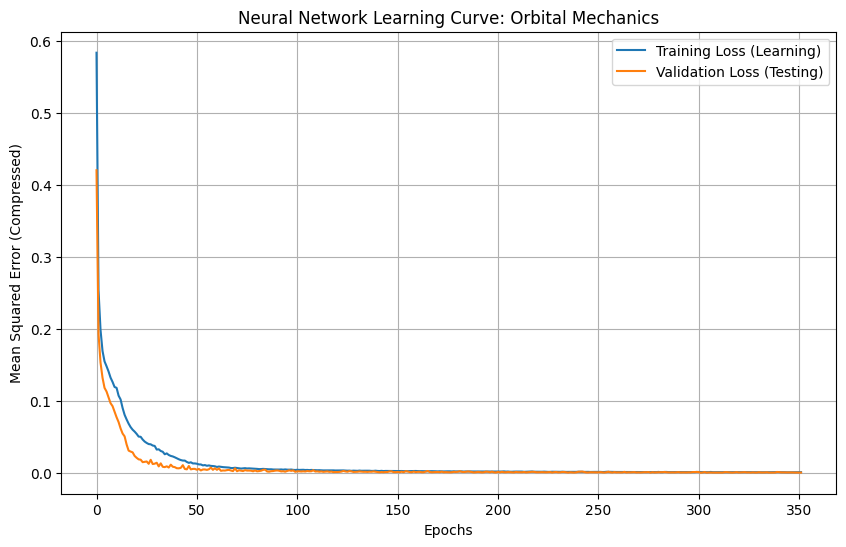

Real-World MSE (Meters Squared): 4.86e+17


In [ ]:
# The purpose of this cell is to visualize training performance and compute real-world error

import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

# plots training vs validation loss
plt.figure(figsize=(10, 6))
plt.plot(space.history['loss'], label='Training Loss')
plt.plot(space.history['val_loss'], label='Validation Loss')

plt.title('Neural Network Learning Curve: Orbital Mechanics')
plt.xlabel('Epochs')
plt.ylabel('Mean Squared Error')
plt.legend()
plt.grid(True)
plt.show()

# computes final real-world error in physical units
all_predictions_scaled = model.predict(X_test, verbose=0)
all_predictions_real = y_scaler.inverse_transform(all_predictions_scaled)
all_actuals_real = y_scaler.inverse_transform(y_test)
real_mse = mean_squared_error(all_actuals_real, all_predictions_real)

print(f"Real-World MSE (Meters Squared): {real_mse:.2e}")

In [ ]:
# The purpose of this cell is to save the trained model and preprocessing scalers

import joblib

# saves trained neural network model
model.save('/content/drive/MyDrive/ColabNotebooks/solar_system_ai.keras')

# saves feature scalers for inference pipeline
joblib.dump(X_scaler, '/content/drive/MyDrive/ColabNotebooks/X_scaler.pkl')
joblib.dump(y_scaler, '/content/drive/MyDrive/ColabNotebooks/y_scaler.pkl')

['/content/drive/MyDrive/ColabNotebooks/y_scaler.pkl']